### Explore Data in CVS file ###

In [10]:
from tools import clean_phone

import numpy as np
import pandas as pd

*INSPECTION PHASE*

In [11]:
df = pd.read_csv("customers-100.csv")

df.head()

,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website
0,1,0yJn77tfsE,Stephanie,Fuentes,"Gillespie, Chapman and Evans",West Alexfort,Falkland Islands (Malvinas),+1-940-986-3836x4639,323-571-0575,roger59@michael.com,2020-05-01,http://www.lyons-stokes.com/
1,2,Hra1WmR9Po,Pedro,Gallagher,"Peterson, Hammond and Mathews",North Lydiaport,Cocos (Keeling) Islands,471-230-5797x8855,965-338-5154x6484,sawyerbarbara@bush.info,2023-04-11,http://www.montes.com/
2,3,8lx51Qhdi6,Sabrina,Blake,Miranda and Sons,New Colton,Honduras,+1-380-937-3274x28965,634.731.3884x537,chris47@bennett.biz,2025-07-19,http://www.castaneda.info/
3,4,B3gClcL1Po,Pedro,Rubio,Bradley-Wong,New Kristopher,South Georgia and the South Sandwich Islands,(818)877-7517,6618384328,kristennelson@berger.com,2021-10-28,https://erickson.com/
4,5,3G5SUK3TxV,Alice,Howe,Jordan-Ingram,Garciamouth,Papua New Guinea,261.627.9677x4648,(802)411-9292,richardsonstephen@weiss-clarke.org,2024-10-28,http://hall-sosa.org/


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Index              100 non-null    int64 
 1   Customer Id        100 non-null    object
 2   First Name         100 non-null    object
 3   Last Name          100 non-null    object
 4   Company            100 non-null    object
 5   City               100 non-null    object
 6   Country            100 non-null    object
 7   Phone 1            100 non-null    object
 8   Phone 2            100 non-null    object
 9   Email              100 non-null    object
 10  Subscription Date  100 non-null    object
 11  Website            100 non-null    object
dtypes: int64(1), object(11)
memory usage: 9.5+ KB


In [13]:
df.isnull().sum()

Index                0
Customer Id          0
First Name           0
Last Name            0
Company              0
City                 0
Country              0
Phone 1              0
Phone 2              0
Email                0
Subscription Date    0
Website              0
dtype: int64

No missing value
Phone numbers 1,2 are inconsistent so that needs to be cleaned
Subscription dtype is object which is string so that need to be changed to Date for data analysis 


*CLEANING PHASE*

In [14]:
# Convert Subscription date to Date type
df['Subscription Date'].head()

0    2020-05-01
1    2023-04-11
2    2025-07-19
3    2021-10-28
4    2024-10-28
Name: Subscription Date, dtype: object

In [15]:
df['Subscription Date'] = pd.to_datetime(df['Subscription Date'])
df['Subscription Date'].head(3)

0   2020-05-01
1   2023-04-11
2   2025-07-19
Name: Subscription Date, dtype: datetime64[ns]

In [16]:
df['Subscription Date'].dt.year.head()

0    2020
1    2023
2    2025
3    2021
4    2024
Name: Subscription Date, dtype: int32

In [17]:
# Standrize Phone number 1,2
df['Phone 1'].head(10)

0     +1-940-986-3836x4639
1        471-230-5797x8855
2    +1-380-937-3274x28965
3            (818)877-7517
4        261.627.9677x4648
5        (534)997-7624x626
6        (284)766-2527x223
7             443.565.6769
8      +1-704-504-2914x567
9            (417)999-0933
Name: Phone 1, dtype: object

In [18]:
# remove extension
df['Phone 1'] = df['Phone 1'].apply(clean_phone)

df['Phone 1'].head()

0    +19409863836
1    +14712305797
2    +13809373274
3    +18188777517
4    +12616279677
Name: Phone 1, dtype: object

In [19]:
df['Phone 2'].head(10)

0              323-571-0575
1         965-338-5154x6484
2          634.731.3884x537
3                6618384328
4             (802)411-9292
5             (688)366-4237
6    001-367-429-8545x54065
7        579-288-6216x54865
8              449.626.4757
9          908.869.2829x840
Name: Phone 2, dtype: object

In [20]:
df['Phone 2'] = df['Phone 2'].apply(clean_phone)

df['Phone 2'].head()

0    +13235710575
1    +19653385154
2    +16347313884
3    +16618384328
4    +18024119292
Name: Phone 2, dtype: object

*EXPLORING DATA*

In [21]:
# Customers by country

df['Country'].unique()

array(['Falkland Islands (Malvinas)', 'Cocos (Keeling) Islands',
       'Honduras', 'South Georgia and the South Sandwich Islands',
       'Papua New Guinea', 'Spain', 'Monaco', 'Marshall Islands',
       'Switzerland', 'Guyana', 'Bermuda', 'Burundi', 'Guinea-Bissau',
       'Lesotho', 'Hong Kong', 'United Arab Emirates', 'Canada',
       'San Marino', 'Niue', 'Montserrat', 'Austria', 'Sierra Leone',
       'Grenada', 'Venezuela', 'Micronesia', 'Argentina', 'Tunisia',
       'Denmark', 'Central African Republic', 'Zimbabwe', 'Tuvalu',
       'Afghanistan', 'Philippines', 'Romania', 'Slovenia', 'Ukraine',
       'Niger', 'Ghana', 'Ireland', 'Swaziland',
       'Northern Mariana Islands', 'Uzbekistan',
       'Slovakia (Slovak Republic)', 'Italy', 'Bangladesh', 'Myanmar',
       'Cameroon', 'Samoa', 'Belgium', 'Taiwan', 'Korea', 'Congo',
       'Wallis and Futuna', 'Rwanda', 'Ethiopia', 'Fiji',
       'Saint Kitts and Nevis', 'Norway', 'Peru',
       'British Virgin Islands', 'Mayotte', 

In [24]:
# Top 10 countries

df['Country'].value_counts().head(10)

Country
Uzbekistan                  3
Spain                       3
Rwanda                      3
Northern Mariana Islands    2
Sao Tome and Principe       2
Belgium                     2
Korea                       2
Swaziland                   2
Micronesia                  2
Sierra Leone                2
Name: count, dtype: int64

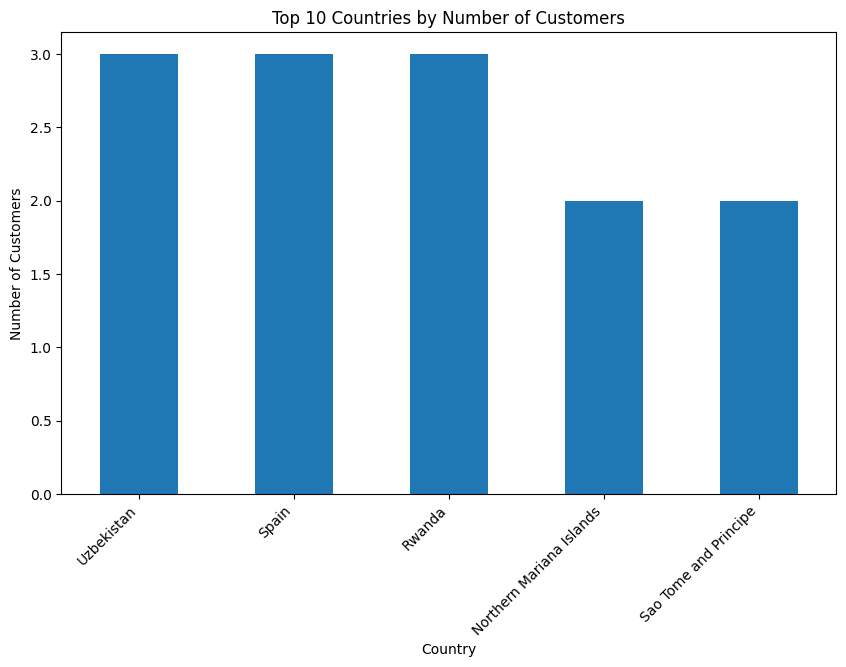

In [30]:
# Visualize Top 10 countries with Bar chart

top_countries = df['Country'].value_counts().head()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
top_countries.plot(kind="bar")
plt.title("Top 10 Countries by Number of Customers")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha="right")
plt.show()

In [31]:
# % of cusomters by country 

(df['Country'].value_counts(normalize=True) * 100).head(10)

Country
Uzbekistan                  3.0
Spain                       3.0
Rwanda                      3.0
Northern Mariana Islands    2.0
Sao Tome and Principe       2.0
Belgium                     2.0
Korea                       2.0
Swaziland                   2.0
Micronesia                  2.0
Sierra Leone                2.0
Name: proportion, dtype: float64

In [32]:
# Customers by Year

df['Subscription Date'].dt.year

0     2020
1     2023
2     2025
3     2021
4     2024
      ... 
95    2023
96    2021
97    2023
98    2021
99    2025
Name: Subscription Date, Length: 100, dtype: int32

In [34]:
df['Year'] = df['Subscription Date'].dt.year

In [35]:
df['Year'].value_counts().sort_index()

Year
2020    19
2021    24
2022    12
2023    19
2024    17
2025     9
Name: count, dtype: int64

1. 2021 is our peak year

With 24 customers, 2021 is highest growth period.

Could indicate:

A marketing campaign

Product launch

Seasonal trends

Better lead generation

2. 2022 shows a drop

Only 12, which is significantly lower.
This could be noise in synthetic data, or a real pattern in real datasets.

3. 2023 & 2024 stabilized

Both 17–19, suggesting consistent retention or steady acquisition.

4. 2025 is incomplete

Only 9 customers — likely because:

The year is ongoing

Data hasn't fully been recorded

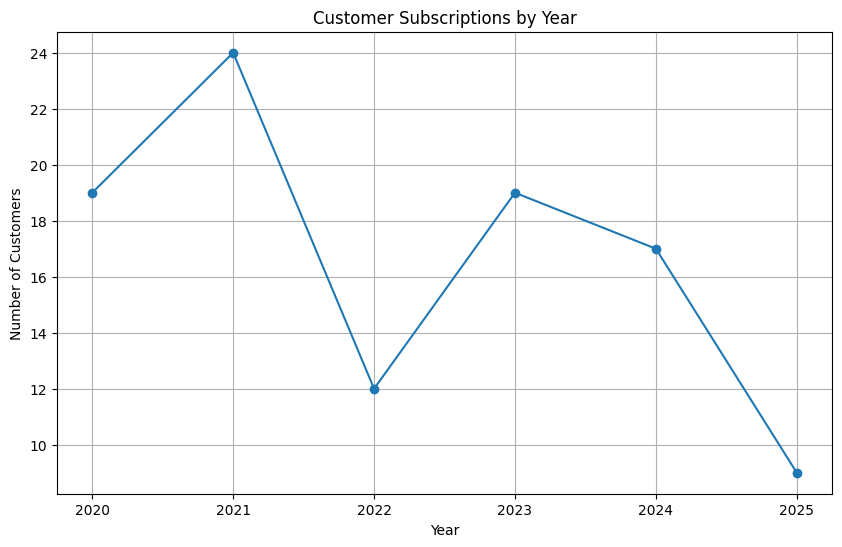

In [36]:
# vidsuliaze the trend

years_count = df['Year'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.plot(years_count.index, years_count.values, marker='o')
plt.title("Customer Subscriptions by Year")
plt.xlabel("Year")
plt.ylabel("Number of Customers")
plt.grid(True)
plt.show()

In [37]:
# Correlation-like analysis (e.g., which countries have early vs. late signups)

country_year = df.groupby("Country")["Year"].mean().sort_values()
country_year

Country
Norway                         2020.0
Falkland Islands (Malvinas)    2020.0
Kazakhstan                     2020.0
Kuwait                         2020.0
Latvia                         2020.0
                                ...  
Bermuda                        2025.0
Samoa                          2025.0
New Zealand                    2025.0
Honduras                       2025.0
Solomon Islands                2025.0
Name: Year, Length: 80, dtype: float64

In [39]:
country_year.head(10)

Country
Norway                         2020.0
Falkland Islands (Malvinas)    2020.0
Kazakhstan                     2020.0
Kuwait                         2020.0
Latvia                         2020.0
Ghana                          2020.0
Burundi                        2020.0
British Virgin Islands         2020.0
Guyana                         2020.0
Ukraine                        2020.0
Name: Year, dtype: float64

In [40]:
country_year.tail(10)

Country
Cayman Islands       2024.0
Wallis and Futuna    2024.0
Congo                2024.0
Papua New Guinea     2024.0
Slovenia             2025.0
Bermuda              2025.0
Samoa                2025.0
New Zealand          2025.0
Honduras             2025.0
Solomon Islands      2025.0
Name: Year, dtype: float64

📊 Earliest Adopter Countries (avg year = 2020)

These countries all have an average subscription year of 2020.0, meaning:
All (or almost all) customers from these countries signed up in 2020.
They were early adopters in your dataset.
Your earliest adopters include:

Norway
Falkland Islands (Malvinas)
Kazakhstan
Kuwait
Latvia

These represent regions that engaged with your product earliest.
📈 Latest Adopter Countries (avg year = 2025)
These all have an average subscription year of 2025.0, meaning:
Customers from these countries are signing up in the latest year.
Indicates recent increase in interest.

Your latest adopters include:

Bermuda
Samoa
New Zealand
Honduras
Solomon Islands

These regions are showing new growth.

🎯 What This Insight Means
✔ Revealed geographic trends over time

Some countries sign up early, others late — this matters for:

Marketing segmentation
Product launch timing
Adoption curve analysis
Targeting new or emerging regions

✔ Even detect “waves” of adoption

If more countries cluster in late years (2024–2025), the product is gaining traction globally.